In [1]:
!pip install -q hazm nltk fasttext tqdm transformers


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 4.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.6/886.6 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.6/562.6 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install numpy>=2.0
!pip install scikit-learn>=1.7,<2
!pip install hazm
!pip install torch transformers plotly seaborn matplotlib pandas


/bin/bash: line 1: 2: No such file or directory


In [3]:
import numpy as np
import pandas as pd
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score


In [4]:
import sklearn
print(sklearn.__version__)


1.8.0


In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [6]:
pd.set_option('display.max_colwidth', None)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

dataset_folder = "/content/drive/My Drive/sentiment_analysis_project/dataset/"
print(os.listdir(dataset_folder))

file_path = os.path.join(dataset_folder, "Snappfood - Sentiment Analysis.csv")

import pandas as pd
df = pd.read_csv(file_path, sep="\t")
df.head()




['Snappfood - Sentiment Analysis.csv']


,Unnamed: 0,comment,label,label_id
0,NaN,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1.0
1,NaN,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم و سالهاست مزه بهشت میده غذاشون,HAPPY,0.0
2,NaN,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,1.0
3,NaN,عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم,HAPPY,0.0
4,NaN,شیرینی وانیلی فقط یک مدل بود.,HAPPY,0.0


In [9]:
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  520 non-null    object 
 1   comment     70000 non-null  object 
 2   label       70000 non-null  object 
 3   label_id    69480 non-null  float64
dtypes: float64(1), object(3)
memory usage: 2.1+ MB


Index(['Unnamed: 0', 'comment', 'label', 'label_id'], dtype='object')

In [10]:
df.shape

(70000, 4)

In [11]:
df.drop('Unnamed: 0', axis=1, inplace=True)
df.shape

(70000, 3)

In [12]:
df.dropna(inplace=True)
df.shape

(69480, 3)

In [13]:
df['label'] = df['label'].str.upper().str.strip()


In [14]:
df[['label', 'label_id']].value_counts()

,,count
label,label_id,
HAPPY,0.0,34916
SAD,1.0,34564


In [15]:
df['label_id'] = 1 - df['label_id']

In [16]:
df = df[~((df['label'] == 'HAPPY') & (df['label_id'] != 1))]
df = df[~((df['label'] == 'SAD') & (df['label_id'] != 0))]


In [17]:
df['label_id'] = df['label_id'].astype(int)
labels = ['HAPPY', 'SAD']


In [18]:
df.head(20)

,comment,label,label_id
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,0
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم و سالهاست مزه بهشت میده غذاشون,HAPPY,1
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,0
3,عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم,HAPPY,1
4,شیرینی وانیلی فقط یک مدل بود.,HAPPY,1
5,بدترین پیتزایی که تا به حال خورده بودم,SAD,0
6,از همه لحاظ عالی ممنونم,HAPPY,1
7,کیفیت غذا متوسط رو به پایین بود انگار داخل یه رستوران معمولی غذا خوردی درحالی که امتیاز رستوران در اسنپ فود ۴٫۳ بود,SAD,0
8,همه اقلام تازه و به روز وخیلیییییی سریع بدستم رسید واقعا متشکرم,HAPPY,1
9,همه چی خوب ولی هات داگ دورش کلا سوخته بود و داخلش خام بود!!!!,SAD,0


In [19]:
df.drop_duplicates(subset=['comment'], keep='first', inplace=True)

In [20]:
df = df[~df['comment'].str.contains(r'[a-zA-Z]', na=False)]
df.shape

(69118, 3)

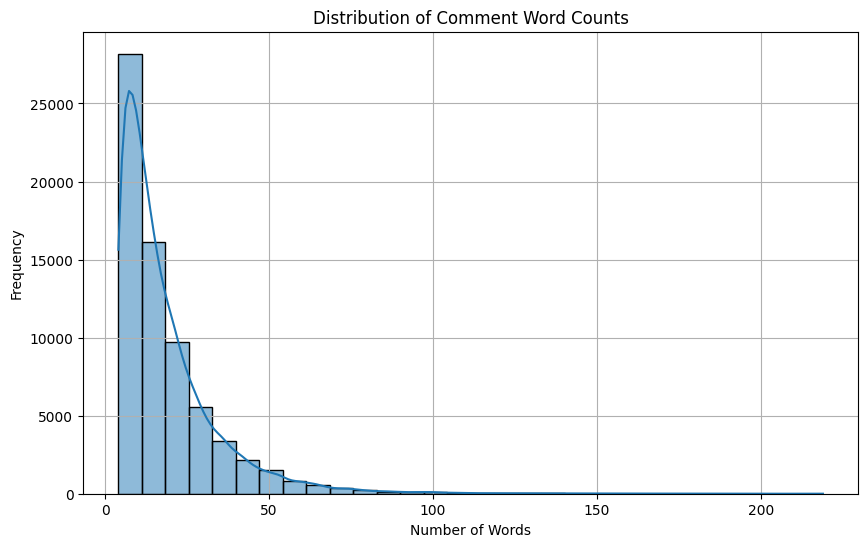

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title('Distribution of Comment Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [22]:
df['word_count'].describe()


,word_count
count,69118.000000
mean,18.638604
std,15.734903
min,4.000000
25%,8.000000
50%,14.000000
75%,24.000000
max,219.000000


In [23]:
df['word_count'].quantile([0.9, 0.95, 0.99])

,word_count
0.90,38.0
0.95,49.0
0.99,78.0


In [24]:
df = df.reset_index(drop=True)

In [25]:
df.head(20)

,comment,label,label_id,word_count
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,0,9
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم و سالهاست مزه بهشت میده غذاشون,HAPPY,1,26
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,0,17
3,عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم,HAPPY,1,20
4,شیرینی وانیلی فقط یک مدل بود.,HAPPY,1,6
5,بدترین پیتزایی که تا به حال خورده بودم,SAD,0,8
6,از همه لحاظ عالی ممنونم,HAPPY,1,5
7,کیفیت غذا متوسط رو به پایین بود انگار داخل یه رستوران معمولی غذا خوردی درحالی که امتیاز رستوران در اسنپ فود ۴٫۳ بود,SAD,0,23
8,همه اقلام تازه و به روز وخیلیییییی سریع بدستم رسید واقعا متشکرم,HAPPY,1,12
9,همه چی خوب ولی هات داگ دورش کلا سوخته بود و داخلش خام بود!!!!,SAD,0,14


In [26]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
comment,69118,69118,فلفلش خییییلی تند بود.,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,69118,2,HAPPY,34709,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label_id,69118.0,NaN,NaN,NaN,0.50217,0.499999,0.0,0.0,1.0,1.0,1.0
word_count,69118.0,NaN,NaN,NaN,18.638604,15.734903,4.0,8.0,14.0,24.0,219.0


In [27]:
X = (df['comment'])
y = (df['label_id'])
X.shape, y.shape

((69118,), (69118,))

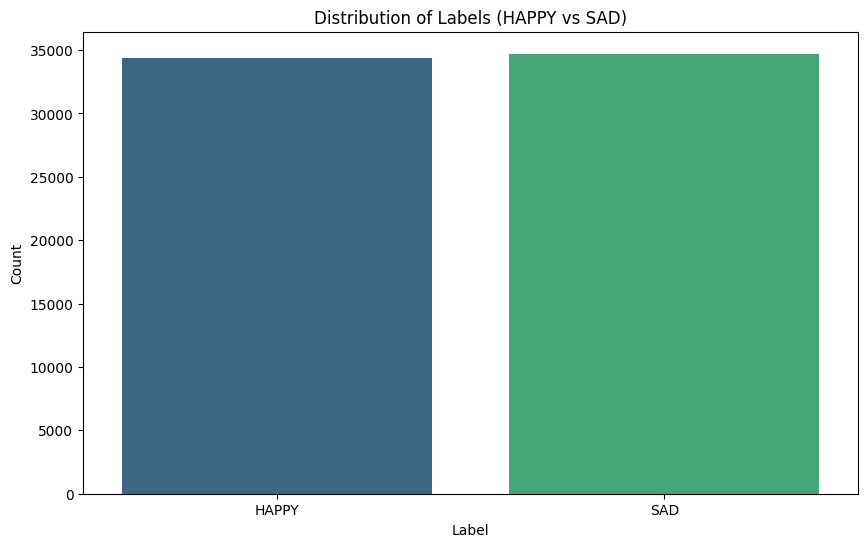

In [28]:
label_counts = df['label_id'].value_counts()


plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title('Distribution of Labels (HAPPY vs SAD)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=["HAPPY", "SAD"])
plt.show()

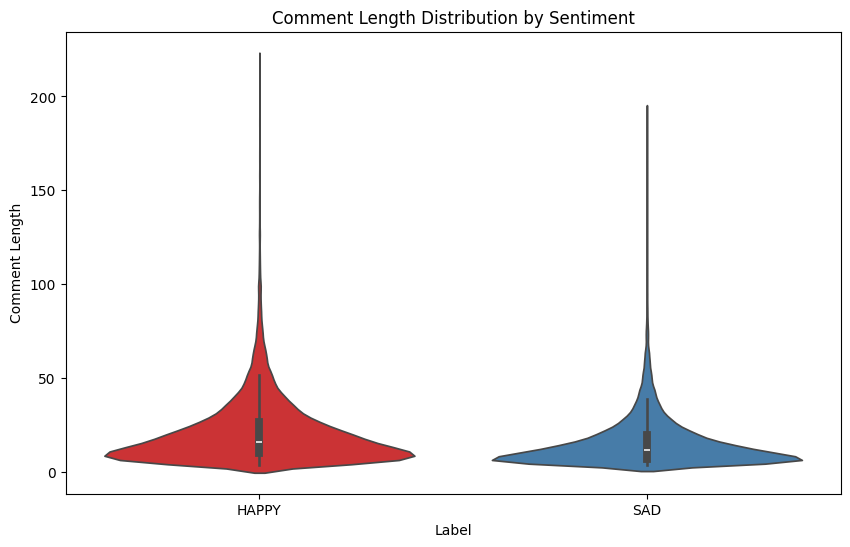

In [29]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='label_id', y='word_count', data=df, palette="Set1")
plt.title('Comment Length Distribution by Sentiment')
plt.xlabel('Label')
plt.ylabel('Comment Length')
plt.xticks(ticks=[0, 1], labels=["HAPPY", "SAD"])
plt.show()

In [ ]:
pip install --upgrade scikit-learn


  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)


In [ ]:
pip install --no-deps hazm

In [ ]:
pip uninstall scikit-learn -y

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0


In [ ]:
pip install scikit-learn==1.3.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 41.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hazm 0.11.0 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
hazm 0.11.0 requires scikit-learn<2.0.0,>=1.7.2, but you have scikit-learn 1.3.2 which is incompatible.
opencv-python-headless 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, 

In [30]:

import re


use_hazm = False
try:
    from hazm import Normalizer, Lemmatizer
    normalizer = Normalizer()
    lemmatizer = Lemmatizer()
    use_hazm = True
except ImportError:
    pass


persian_stopwords = set([
    "و", "در", "به", "از", "که", "این", "با", "را", "برای",
    "اما", "یا", "اگر", "نه", "هم", "تا", "یک", "من", "تو",
    "ایشان","بود","داشت","خواه","کند","همین"
])


def normalize_persian(text):
    text = text.replace("ي", "ی").replace("ك", "ک")
    return text

def remove_noise(text):
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    return text

def remove_english_and_digits(text):
    text = re.sub(r"[A-Za-z]", " ", text)
    text = re.sub(r"[0-9٠-٩۰-۹]", " ", text)
    return text

def remove_punctuation_keep_persian(text):
    return re.sub(r"[^\u0600-\u06FF\s‌]", " ", text)

def remove_stretch(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)

def fix_spaces_and_halfspace(text):
    text = text.replace("\u200c", "‌")
    return re.sub(r"\s+", " ", text).strip()

def remove_stopwords_func(text):
    words = [w for w in text.split() if w and w not in persian_stopwords]
    return " ".join(words)

def simple_lemmatize(word):
    orig = word
    for suf in ["تر", "ترین", "ها", "های", "ام", "ی", "هایم", "هایش", "شان", "ترين"]:
        if word.endswith(suf) and len(word) - len(suf) > 2:
            return word[:-len(suf)]
    for pref in ["می", "نمی", "بی"]:
        if word.startswith(pref) and len(word) - len(pref) > 2:
            return word[len(pref):]
    return orig

def lemmatize_text(text):
    tokens = text.split()
    if use_hazm:
        try:
            return " ".join([lemmatizer.lemmatize(t) for t in tokens])
        except Exception:
            return " ".join([simple_lemmatize(t) for t in tokens])
    else:
        return " ".join([simple_lemmatize(t) for t in tokens])

def remove_spam_and_short(text):
    if not isinstance(text, str): return ""
    if re.search(r"(www|http|@)", text): return ""
    if re.search(r"\d{6,}", text): return ""
    if len(text.split()) <= 1: return ""
    return text

# -Preprocess Manager
class PreprocessManager:
    def __init__(self):
        pass

    #  Classic models: heavy cleaning
    def classic_pipeline(self, text):
        t = text
        if use_hazm:
            try: t = normalizer.normalize(t)
            except: pass
        t = t.lower()
        t = normalize_persian(t)
        t = remove_noise(t)
        t = remove_english_and_digits(t)
        t = remove_punctuation_keep_persian(t)
        t = remove_stretch(t)
        t = fix_spaces_and_halfspace(t)


        t = fix_spaces_and_halfspace(t)
        t = remove_spam_and_short(t)
        return t

    #  Neural models: medium cleaning
    def neural_pipeline(self, text):
        t = text
        if use_hazm:
            try: t = normalizer.normalize(t)
            except: pass
        t = t.lower()
        t = normalize_persian(t)
        t = remove_noise(t)
        t = remove_punctuation_keep_persian(t)
        t = fix_spaces_and_halfspace(t)

        return t

    #  BERT: minimal cleaning
    def bert_pipeline(self, text):
        if not isinstance(text, str):
            return ""
        t = text.lower().strip()
        t = normalize_persian(t)
        t = re.sub(r"http\S+|www\S+|\S+@\S+", " ", t)  # urls/emails
        t = re.sub(r"\s+", " ", t)
        return t

    #  Unified preprocess function
    def preprocess(self, text, model_type="classic"):
        """
        model_type: "classic", "neural", "bert"
        """
        if model_type == "classic":
            return self.classic_pipeline(text)
        elif model_type == "neural":
            return self.neural_pipeline(text)
        elif model_type == "bert":
            return self.bert_pipeline(text)
        else:
            # fallback
            return self.neural_pipeline(text)


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      6857
           1       0.90      0.82      0.86      6967

    accuracy                           0.86     13824
   macro avg       0.87      0.86      0.86     13824
weighted avg       0.87      0.86      0.86     13824



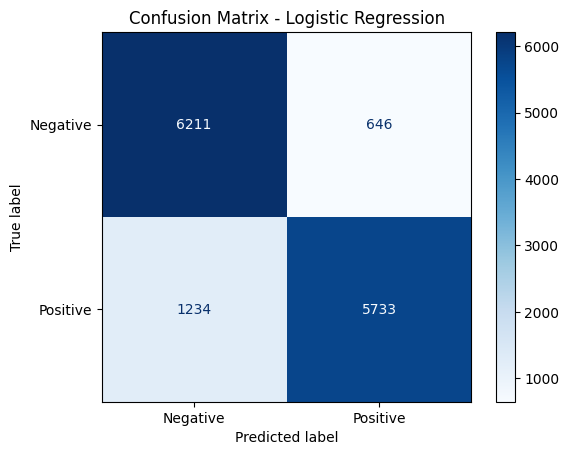


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      6857
           1       0.89      0.80      0.84      6967

    accuracy                           0.85     13824
   macro avg       0.86      0.85      0.85     13824
weighted avg       0.86      0.85      0.85     13824



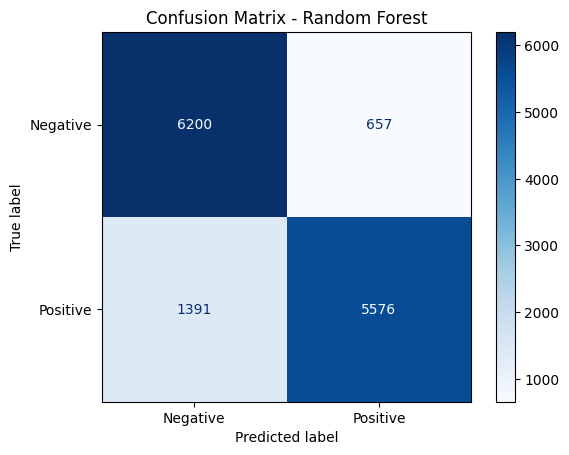


Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.82      0.92      0.86      6857
           1       0.91      0.80      0.85      6967

    accuracy                           0.86     13824
   macro avg       0.86      0.86      0.86     13824
weighted avg       0.86      0.86      0.86     13824



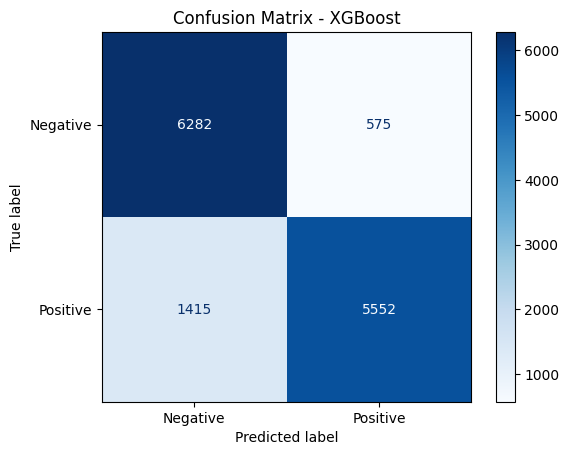

In [ ]:

preprocessor = PreprocessManager()



X_train, X_test, y_train, y_test = train_test_split(X.copy(), y.copy(), test_size=0.2, random_state=42)


# Apply preprocessing steps on the training and testing sets separately
X_train_proc = X_train.apply(lambda x: preprocessor.preprocess(x, model_type="classic"))
X_test_proc = X_test.apply(lambda x: preprocessor.preprocess(x, model_type="classic"))

# Convert text data into numerical features using TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=6000,
    ngram_range=(1,2),
    min_df=3
)
X_train_vec = vectorizer.fit_transform(X_train_proc)
X_test_vec = vectorizer.transform(X_test_proc)

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier()
}

classification_reports = {}

for model_name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred))
    classification_reports[model_name] = classification_report(y_test, y_pred, output_dict=True)

        # ===== Confusion Matrix =====
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Negative', 'Positive']  # اگر 0/1 هست
    )

    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

<Figure size 1200x600 with 0 Axes>

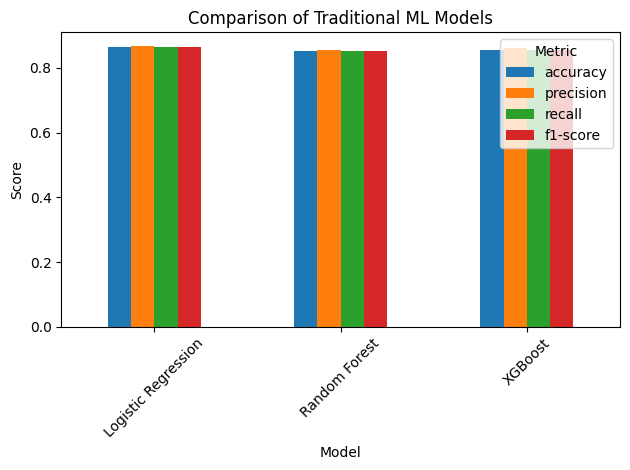

In [ ]:
metrics = ['accuracy', 'precision', 'recall', 'f1-score']
metrics_values = {metric: [] for metric in metrics}

for model_name, report in classification_reports.items():
    metrics_values['accuracy'].append(report['accuracy'])
    for metric in ['precision', 'recall', 'f1-score']:
        metrics_values[metric].append(report['macro avg'][metric])

# Create DataFrame for plotting
metrics_df = pd.DataFrame(metrics_values, index=models.keys())

# Plot the metrics
plt.figure(figsize=(12,6))
metrics_df.plot(kind='bar')
plt.title('Comparison of Traditional ML Models')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [ ]:
import pickle, os

output_dir = "/content/drive/MyDrive/sentiment_analysis_project/models"
os.makedirs(output_dir, exist_ok=True)


vectorizer_file = os.path.join(output_dir, "tfidf_vectorizer.pkl")
with open(vectorizer_file, "wb") as f:
    pickle.dump(vectorizer, f)

print("TF-IDF vectorizer saved.")


TF-IDF vectorizer saved.


In [ ]:
for name, model in models.items():
    model_file = os.path.join(output_dir, f"{name.replace(' ', '_')}.pkl")
    with open(model_file, "wb") as f:
        pickle.dump(model, f)
    print(f"{name} saved to {model_file}")


Logistic Regression saved to /content/drive/MyDrive/sentiment_analysis_project/models/Logistic_Regression.pkl
Random Forest saved to /content/drive/MyDrive/sentiment_analysis_project/models/Random_Forest.pkl
XGBoost saved to /content/drive/MyDrive/sentiment_analysis_project/models/XGBoost.pkl


In [ ]:

with open(vectorizer_file, "rb") as f:
    vectorizer = pickle.load(f)


loaded_models = {}
for name in models.keys():
    model_file = os.path.join(output_dir, f"{name.replace(' ', '_')}.pkl")
    with open(model_file, "rb") as f:
        loaded_models[name] = pickle.load(f)




In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import numpy as np
from tqdm import tqdm
from collections import Counter

In [ ]:

preprocessor = PreprocessManager()
X_copy = X.copy()
y_copy = y.copy()

X_train, X_temp, y_train, y_temp = train_test_split(X_copy, y_copy, test_size=0.3, random_state=42, stratify=y_copy)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train_proc = X_train.apply(lambda x: preprocessor.preprocess(x, model_type="neural"))
X_test_proc = X_test.apply(lambda x: preprocessor.preprocess(x, model_type="neural"))
X_val_proc = X_val.apply(lambda x: preprocessor.preprocess(x,  model_type="neural"))


# Build Vocabulary
def build_vocab(texts, vocab_size=10000, oov_token='<OOV>'):
    counter = Counter()
    for text in texts:
        tokens = text.split()
        counter.update(tokens)
    most_common = counter.most_common(vocab_size - 2)  # Reserve 0 and 1
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
    vocab['<PAD>'] = 0
    vocab[oov_token] = 1
    return vocab

# Tokenize texts
def texts_to_sequences(texts, vocab, oov_token='<OOV>'):
    return [[vocab.get(word, vocab[oov_token]) for word in text.split()] for text in texts]

# Padding function (PyTorch style)
def pad_sequences_torch(sequences, max_len):
    padded = []
    for seq in sequences:
        if len(seq) < max_len:
            seq = seq + [0] * (max_len - len(seq))
        else:
            seq = seq[:max_len]
        padded.append(torch.tensor(seq, dtype=torch.long))
    return torch.stack(padded)

# Vocabulary and Sequences
vocab = build_vocab(X_train, vocab_size=10000)
X_train_seq = texts_to_sequences(X_t rain_proc, vocab)
X_val_seq = texts_to_sequences(X_val_proc, vocab)
X_test_seq = texts_to_sequences(X_test_proc, vocab=vocab)

# Compute max_len from training set only
train_lens = [len(seq) for seq in X_train_seq]
max_len = int(np.max(train_lens))
print(f"Using max_len = {max_len}")

# Pad sequences to max_len
X_train_pad = pad_sequences_torch(X_train_seq, max_len)
X_val_pad = pad_sequences_torch(X_val_seq, max_len)
X_test_pad = pad_sequences_torch(X_test_seq, max_len)

Using max_len = 189


In [34]:
class TextDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = torch.tensor(labels.values, dtype=torch.float32).squeeze()

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_dataset = TextDataset(X_train_pad, y_train)
val_dataset = TextDataset(X_val_pad, y_val)
test_dataset = TextDataset(X_test_pad, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

In [35]:
import torch
import torch.nn as nn

class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, device):
        super(RNNClassifier, self).__init__()
        self.device = device
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx).to(device)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True).to(device)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        ).to(device)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.rnn(embedded)
        out = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(out).squeeze(1)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, device):
        super(LSTMClassifier, self).__init__()
        self.device = device
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx).to(device)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True).to(device)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        ).to(device)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        out = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(out).squeeze(1)

class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, device):
        super(GRUClassifier, self).__init__()
        self.device = device
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx).to(device)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True).to(device)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        ).to(device)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)
        out = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(out).squeeze(1)


In [36]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=15,
    patience=4,
    device='cpu'
):
    model.to(device)

    train_losses = []
    val_losses = []
    val_accuracies = []

    best_loss = float('inf')
    wait = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        # ===== Train =====
        model.train()
        total_loss = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).float()

            optimizer.zero_grad()
            preds = model(x_batch)          # ⬅️ خروجی sigmoid شده
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ===== Validation =====
        model.eval()
        val_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val = x_val.to(device)
                y_val = y_val.to(device).float()

                preds = model(x_val)
                loss = criterion(preds, y_val)
                val_loss += loss.item()

                bin_preds = (preds >= 0.5).long()
                correct += (bin_preds == y_val.long()).sum().item()
                total += y_val.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # ===== Early stopping =====
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("⛔ Early stopping triggered")
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, val_accuracies


In [37]:
from sklearn.metrics import classification_report

def evaluate_model(model, test_loader, device='cpu'):
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(x_batch)   # ⬅️ قبلاً sigmoid شده
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]

    report = classification_report(all_labels, bin_preds)
    print(report)

    return all_labels, bin_preds


In [38]:

import torch
import torch.nn as nn
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vocab_size = len(vocab)        # ⬅️ خیلی مهم
embed_dim = 128
hidden_dim = 128
pad_idx = vocab['<PAD>']

epochs = 15
patience = 4

criterion = nn.BCELoss()
criterion = nn.BCELoss()

trained_models = {}
training_history = {}

model_classes = {
    "RNN": RNNClassifier,
    "LSTM": LSTMClassifier,
    "GRU": GRUClassifier
}


for name, ModelClass in model_classes.items():
    print(f"\n===== Training {name} =====")

    model = ModelClass(vocab_size, embed_dim, hidden_dim, pad_idx, device)
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

    trained_model, train_losses, val_losses, val_accuracies = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=epochs,
        patience=patience,
        device=device
    )

    trained_models[name] = trained_model
    training_history[name] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies
    }

# ===== Save models (خارج حلقه) =====
for name, model in trained_models.items():
    output_dir = "/content/drive/MyDrive/sentiment_analysis_project/models/"
    path = os.path.join(output_dir, f"{name}_model.pth")
    torch.save(model.state_dict(), path)
    print(f"✅ {name} saved to {path}")



===== Training RNN =====
Epoch 1 | Train Loss: 0.4903 | Val Loss: 0.4311 | Val Acc: 0.7995
Epoch 2 | Train Loss: 0.3987 | Val Loss: 0.3775 | Val Acc: 0.8338
Epoch 3 | Train Loss: 0.3657 | Val Loss: 0.3554 | Val Acc: 0.8433
Epoch 4 | Train Loss: 0.3423 | Val Loss: 0.3571 | Val Acc: 0.8424
Epoch 5 | Train Loss: 0.3238 | Val Loss: 0.3617 | Val Acc: 0.8487
Epoch 6 | Train Loss: 0.3071 | Val Loss: 0.3396 | Val Acc: 0.8554
Epoch 7 | Train Loss: 0.2942 | Val Loss: 0.3404 | Val Acc: 0.8568
Epoch 8 | Train Loss: 0.2731 | Val Loss: 0.3549 | Val Acc: 0.8522
Epoch 9 | Train Loss: 0.2581 | Val Loss: 0.3654 | Val Acc: 0.8535
Epoch 10 | Train Loss: 0.2414 | Val Loss: 0.3657 | Val Acc: 0.8551
⛔ Early stopping triggered

===== Training LSTM =====
Epoch 1 | Train Loss: 0.4514 | Val Loss: 0.3624 | Val Acc: 0.8438
Epoch 2 | Train Loss: 0.3568 | Val Loss: 0.3354 | Val Acc: 0.8557
Epoch 3 | Train Loss: 0.3278 | Val Loss: 0.3299 | Val Acc: 0.8560
Epoch 4 | Train Loss: 0.3079 | Val Loss: 0.3243 | Val Acc: 0.

In [ ]:
import os
import pickle

output_dir = "/content/drive/MyDrive/sentiment_analysis_project/models"
os.makedirs(output_dir, exist_ok=True)


with open(os.path.join(output_dir, "vocab.pkl"), "wb") as f:
    pickle.dump(vocab, f)

with open(os.path.join(output_dir, "vocab.pkl"), "rb") as f:
    vocab = pickle.load(f)

print("vocab saved and loaded successfully!")

vocab saved and loaded successfully!


In [ ]:
import matplotlib.pyplot as plt

def plot_loss(train_losses, val_losses, title):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
def plot_accuracy(val_accuracies, title):
    plt.figure()
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, test_loader, device, title):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            preds = (preds >= 0.5).long().cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y_batch.numpy())

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()


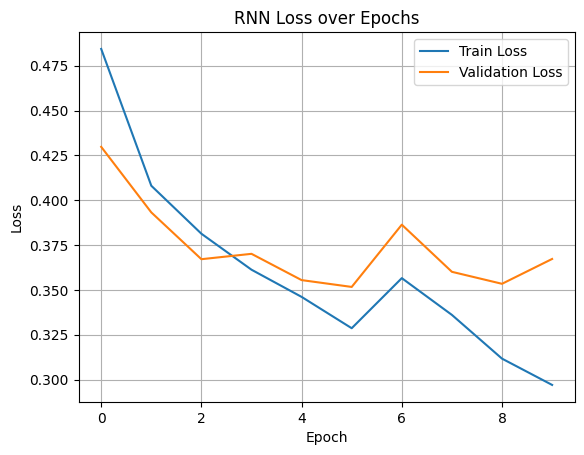

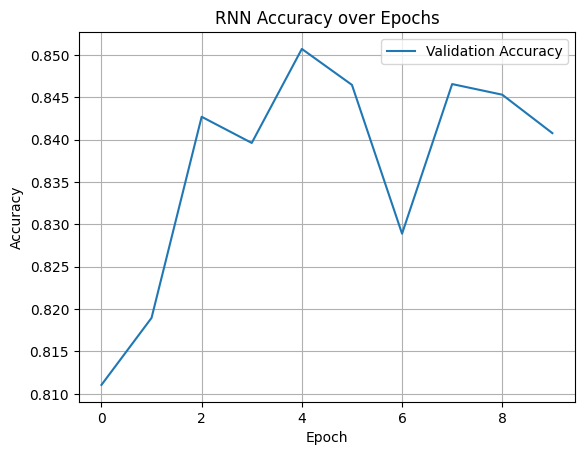

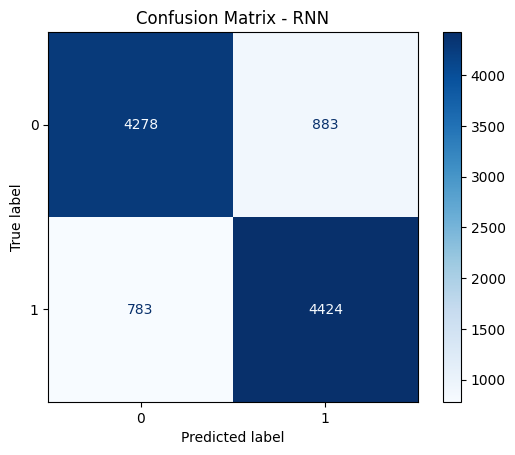

In [ ]:
plot_loss(
    training_history["RNN"]["train_losses"],
    training_history["RNN"]["val_losses"],
    "RNN Loss over Epochs"
)

plot_accuracy(
    training_history["RNN"]["val_accuracies"],
    "RNN Accuracy over Epochs"
)

plot_confusion_matrix(
    trained_models["RNN"],
    test_loader,
    device,
    "Confusion Matrix - RNN"
)


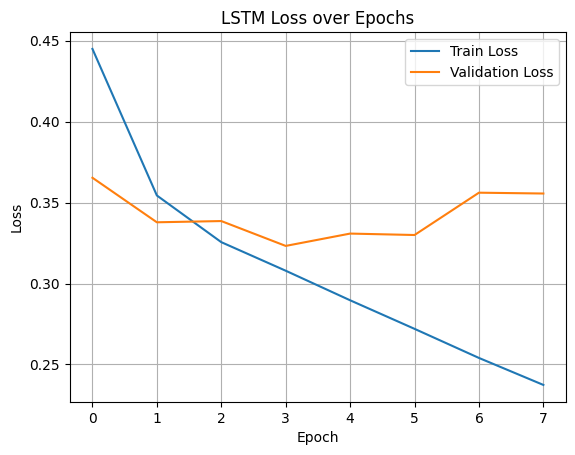

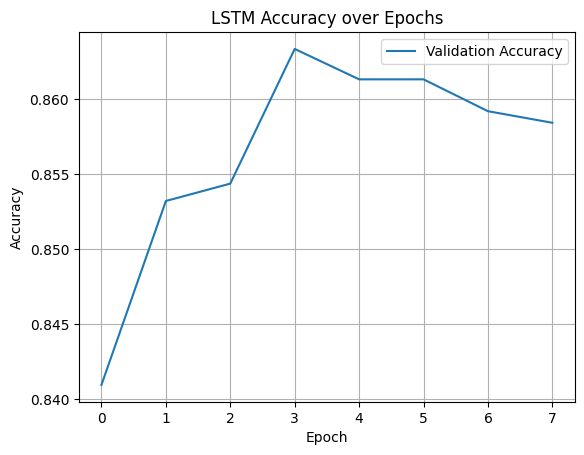

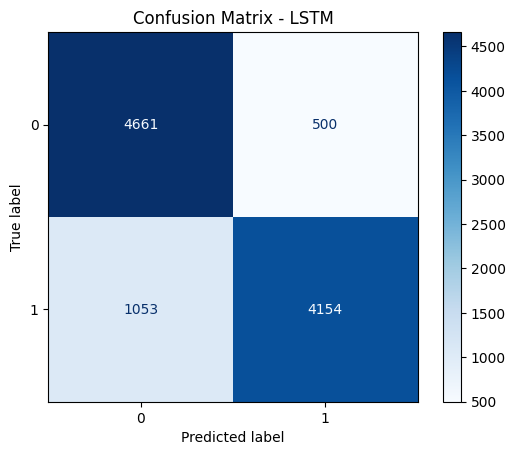

In [ ]:
plot_loss(
    training_history["LSTM"]["train_losses"],
    training_history["LSTM"]["val_losses"],
    "LSTM Loss over Epochs"
)

plot_accuracy(
    training_history["LSTM"]["val_accuracies"],
    "LSTM Accuracy over Epochs"
)

plot_confusion_matrix(
    trained_models["LSTM"],
    test_loader,
    device,
    "Confusion Matrix - LSTM"
)


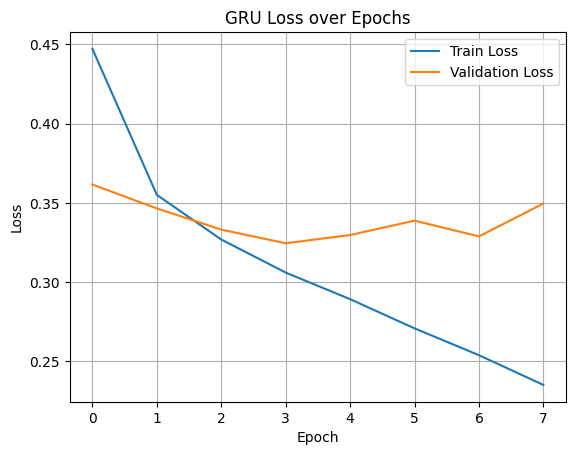

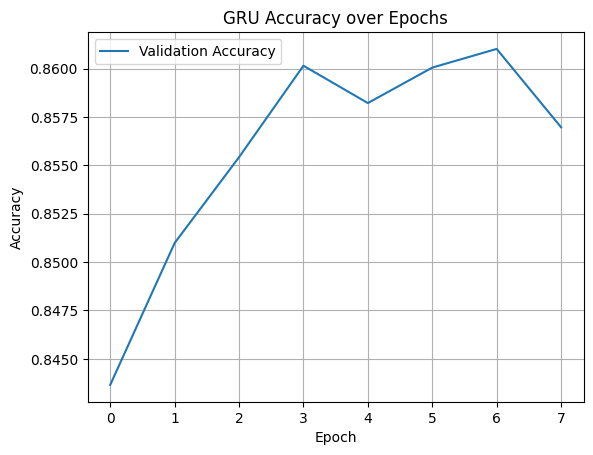

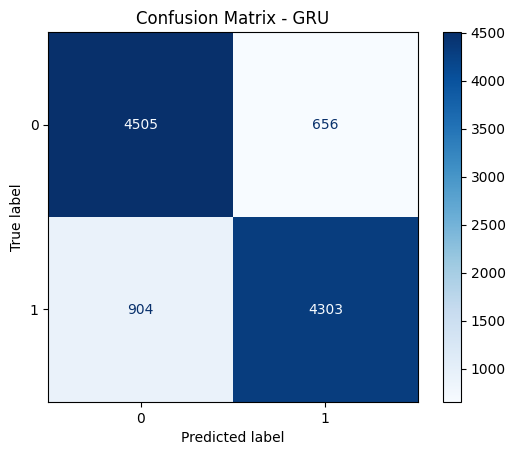

In [ ]:
plot_loss(
    training_history["GRU"]["train_losses"],
    training_history["GRU"]["val_losses"],
    "GRU Loss over Epochs"
)

plot_accuracy(
    training_history["GRU"]["val_accuracies"],
    "GRU Accuracy over Epochs"
)

plot_confusion_matrix(
    trained_models["GRU"],
    test_loader,
    device,
    "Confusion Matrix - GRU"
)


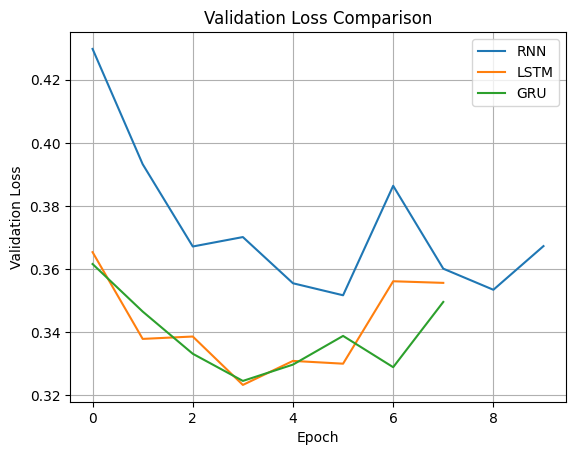

In [ ]:
plt.figure()
for name in ["RNN", "LSTM", "GRU"]:
    plt.plot(
        training_history[name]["val_losses"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()


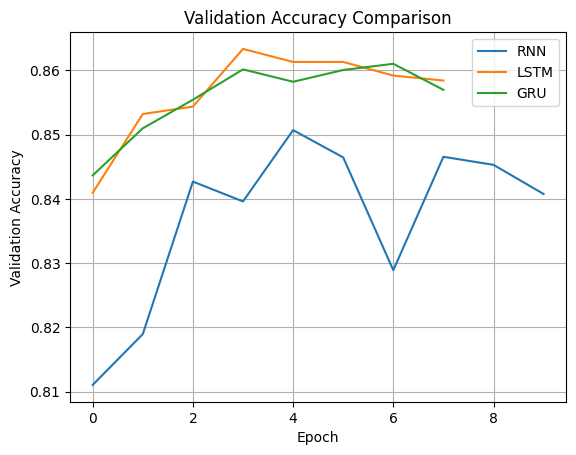

In [ ]:
plt.figure()
for name in ["RNN", "LSTM", "GRU"]:
    plt.plot(
        training_history[name]["val_accuracies"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_metrics(model, test_loader, device='cpu', threshold=0.5):
    model.to(device)
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            probs = model(x_batch)  # sigmoid داخل مدل
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    preds = [1 if p >= threshold else 0 for p in all_probs]

    metrics = {
        # Accuracy کلی
        "accuracy": accuracy_score(all_labels, preds),

        # کلاس 0 (منفی)
        "precision_0": precision_score(all_labels, preds, pos_label=0),
        "recall_0": recall_score(all_labels, preds, pos_label=0),
        "f1_0": f1_score(all_labels, preds, pos_label=0),

        # کلاس 1 (مثبت)
        "precision_1": precision_score(all_labels, preds, pos_label=1),
        "recall_1": recall_score(all_labels, preds, pos_label=1),
        "f1_1": f1_score(all_labels, preds, pos_label=1),
    }

    return metrics



In [41]:
import pandas as pd

df_results = pd.DataFrame(results).T
df_results = df_results.round(4)

df_results


,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1
RNN,0.8438,0.8141,0.8894,0.8501,0.8793,0.7987,0.8371
LSTM,0.8505,0.8331,0.8750,0.8535,0.8696,0.8262,0.8474
GRU,0.8518,0.8059,0.9250,0.8613,0.9129,0.7791,0.8407


In [ ]:
import pandas as pd

df_results = pd.DataFrame(results).T
df_results = df_results.round(4)

df_results


,accuracy,precision,recall,f1-score
RNN,0.8393,0.8336,0.8496,0.8415
LSTM,0.8502,0.8926,0.7978,0.8425
GRU,0.8495,0.8677,0.8264,0.8465


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TextCNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes=1, pad_idx=0, device='cpu',
                 num_filters=100, filter_sizes=[3,4,5], dropout=0.3):
        super(TextCNNClassifier, self).__init__()
        self.device = device
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx).to(device)

        # Convolutional layers with different kernel sizes
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (fs, embed_dim)) for fs in filter_sizes
        ]).to(device)

        # Fully connected layer
        self.fc = nn.Sequential(
            nn.Linear(len(filter_sizes) * num_filters, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
            nn.Sigmoid()  # because binary classification
        ).to(device)

    def forward(self, x):
        """
        x: (batch_size, seq_len)
        """
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        embedded = embedded.unsqueeze(1)  # (batch_size, 1, seq_len, embed_dim) for Conv2d

        # Apply convolution + ReLU + max pooling
        conv_outs = []
        for conv in self.convs:
            c = F.relu(conv(embedded)).squeeze(3)  # remove last dim -> (batch_size, num_filters, seq_len-filter_size+1)
            c = F.max_pool1d(c, c.size(2)).squeeze(2)  # (batch_size, num_filters)
            conv_outs.append(c)

        cat = torch.cat(conv_outs, dim=1)  # (batch_size, num_filters * len(filter_sizes))
        out = self.fc(cat)
        return out.squeeze(1)


Epoch 1 | Train Loss: 0.4562 | Val Loss: 0.3702 | Val Acc: 0.8351
Epoch 2 | Train Loss: 0.3398 | Val Loss: 0.3474 | Val Acc: 0.8453
Epoch 3 | Train Loss: 0.2767 | Val Loss: 0.3497 | Val Acc: 0.8468
Epoch 4 | Train Loss: 0.2083 | Val Loss: 0.3772 | Val Acc: 0.8467
Epoch 5 | Train Loss: 0.1442 | Val Loss: 0.4053 | Val Acc: 0.8385
Epoch 6 | Train Loss: 0.0959 | Val Loss: 0.4690 | Val Acc: 0.8319
⛔ Early stopping triggered
✅ TextCNN full model saved to /content/drive/MyDrive/sentiment_analysis_project/TextCNN_full_model.pth
===== Classification Report =====
              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83      5161
         1.0       0.83      0.83      0.83      5207

    accuracy                           0.83     10368
   macro avg       0.83      0.83      0.83     10368
weighted avg       0.83      0.83      0.83     10368



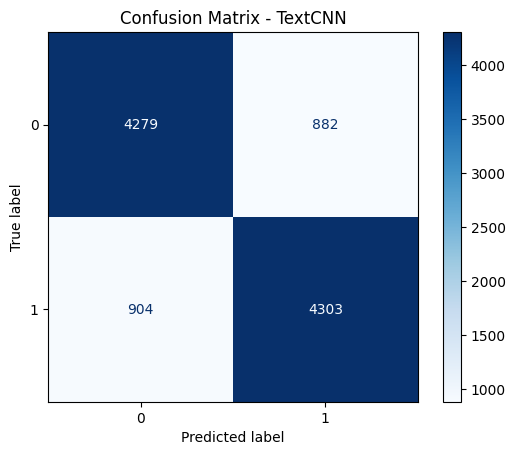

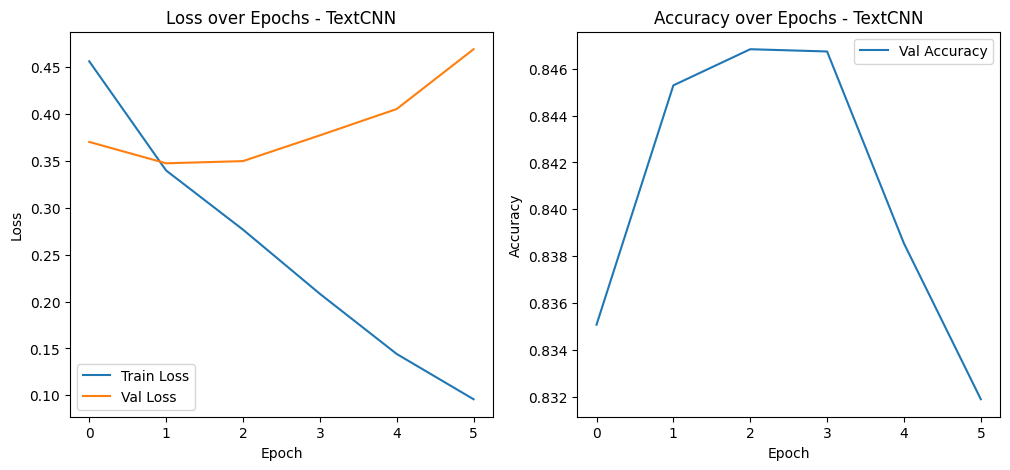

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# ===== Hyperparameters =====
lr = 3e-4
batch_size = 128
embed_dim = 128
num_filters = 100
filter_sizes = [3,4,5]
dropout = 0.3
epochs = 15
patience = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ===== Model =====
model = TextCNNClassifier(
    vocab_size=len(vocab),
    embed_dim=embed_dim,
    pad_idx=vocab['<PAD>'],
    device=device,
    num_filters=num_filters,
    filter_sizes=filter_sizes,
    dropout=dropout
).to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.BCELoss()

# ===== Training loop with early stopping =====
train_losses, val_losses, val_accuracies = [], [], []
best_val_loss = float('inf')
wait = 0

for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ===== Validation =====
    model.eval()
    val_loss, correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            preds = model(x_val)
            loss = criterion(preds, y_val)
            val_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_val.cpu().numpy())
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Accuracy
    bin_preds = [1 if p>=0.5 else 0 for p in all_preds]
    acc = sum([p==l for p,l in zip(bin_preds, all_labels)]) / len(all_labels)
    val_accuracies.append(acc)

    print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = model.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("⛔ Early stopping triggered")
            break

# Load best weights
model.load_state_dict(best_state)

# ===== Save full model =====
output_dir = "/content/drive/MyDrive/sentiment_analysis_project/"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, "TextCNN_full_model.pth")
torch.save(model, save_path)
print(f"✅ TextCNN full model saved to {save_path}")

# ===== Evaluation on test set =====
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        preds = model(x_batch)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

bin_preds = [1 if p>=0.5 else 0 for p in all_preds]

print("===== Classification Report =====")
print(classification_report(all_labels, bin_preds))

# ===== Confusion Matrix =====
cm = confusion_matrix(all_labels, bin_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - TextCNN")
plt.show()

# ===== Plot Loss & Accuracy =====
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs - TextCNN")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs - TextCNN")
plt.legend()

plt.show()


In [ ]:
torch.save(best_state, "/content/drive/MyDrive/sentiment_analysis_project/models/TextCNN_best.pth")


In [ ]:
import torch.nn as nn

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, device):
        super(BiLSTMClassifier, self).__init__()
        self.device = device
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                            batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim*2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(out).squeeze(1)


In [ ]:
def train_model(model, train_loader, val_loader, optimizer, epochs=15, patience=4, device='cpu',save_path=None):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()

    best_loss = float('inf')
    wait = 0
    train_losses, val_losses = [], []
    val_accuracies = []



    for epoch in range(1, epochs+1):
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).float()

            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        all_labels, all_preds = [], []
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val = x_val.to(device)
                y_val = y_val.to(device).float()
                logits = model(x_val)
                loss = criterion(logits, y_val)
                val_loss += loss.item()

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_val.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_acc = accuracy_score(all_labels, all_preds)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            wait = 0
            best_model_state = model.state_dict()
            if save_path:
                torch.save(best_model_state, save_path)
        else:
            wait += 1
            if wait >= patience:
                print("⛔ Early stopping triggered")
                break

    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses, val_accuracies


In [ ]:
def plot_metrics(train_losses, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    # ===== Loss =====
    plt.figure(figsize=(10,4))
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.show()

    # ===== Accuracy =====
    plt.figure(figsize=(10,4))
    plt.plot(epochs, val_accuracies, label='Val Accuracy', color='green')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy over Epochs')
    plt.legend()
    plt.show()

def plot_confusion_matrix(model, test_loader, device='cpu'):
    model.to(device)
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).float()
            logits = model(x_batch)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


Epoch 1 | Train Loss: 0.4497 | Val Loss: 0.3647 | Val Acc: 0.8416
Epoch 2 | Train Loss: 0.3513 | Val Loss: 0.3329 | Val Acc: 0.8567
Epoch 3 | Train Loss: 0.3245 | Val Loss: 0.3298 | Val Acc: 0.8572
Epoch 4 | Train Loss: 0.3054 | Val Loss: 0.3335 | Val Acc: 0.8580
Epoch 5 | Train Loss: 0.2856 | Val Loss: 0.3281 | Val Acc: 0.8594
Epoch 6 | Train Loss: 0.2674 | Val Loss: 0.3488 | Val Acc: 0.8526
Epoch 7 | Train Loss: 0.2475 | Val Loss: 0.3469 | Val Acc: 0.8551
Epoch 8 | Train Loss: 0.2277 | Val Loss: 0.3678 | Val Acc: 0.8553
Epoch 9 | Train Loss: 0.2063 | Val Loss: 0.3748 | Val Acc: 0.8539
⛔ Early stopping triggered
✅ BiLSTM full model saved to /content/drive/MyDrive/sentiment_analysis_project/BiLSTM_full_model.pth


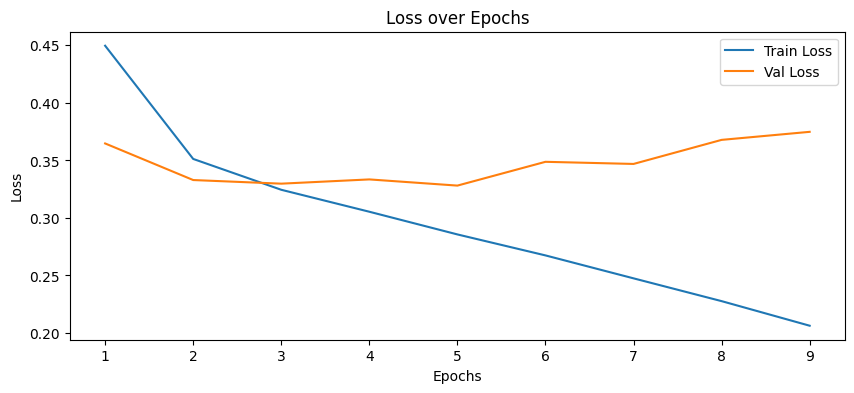

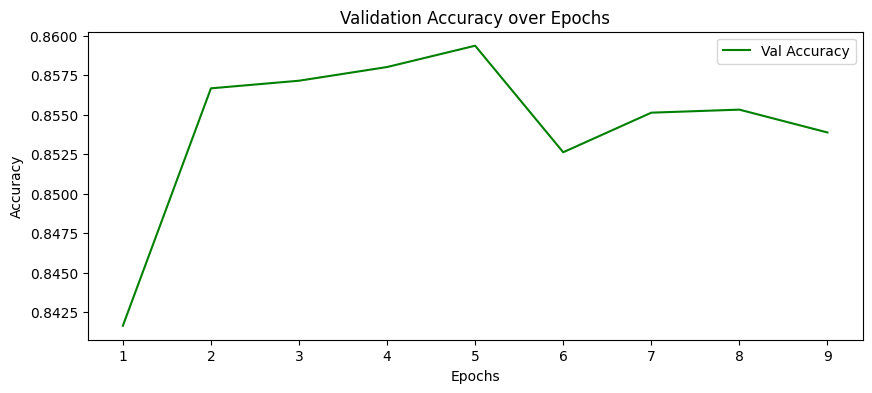

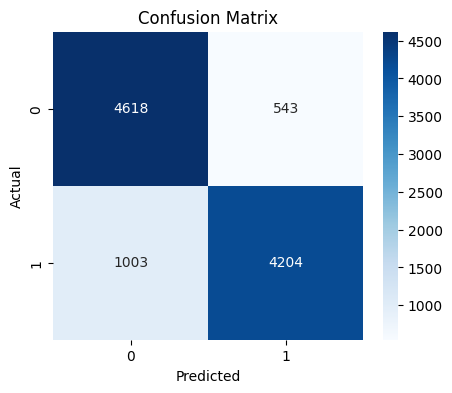

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vocab_size = len(vocab)
embed_dim = 128
hidden_dim = 128
pad_idx = vocab['<PAD>']

# 1. مدل
bilstm_model = BiLSTMClassifier(vocab_size, embed_dim, hidden_dim, pad_idx, device)

# 2. Optimizer
optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=3e-4)

# 3. مسیر ذخیره فول مدل
output_dir = "/content/drive/MyDrive/sentiment_analysis_project/"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, "BiLSTM_full_model.pth")

# 4. آموزش مدل
trained_model, train_losses, val_losses, val_accuracies = train_model(
    bilstm_model,
    train_loader,
    val_loader,
    optimizer,
    epochs=15,
    patience=4,
    device=device
)

# 5. ذخیره فول مدل
torch.save(trained_model, save_path)
print(f"✅ BiLSTM full model saved to {save_path}")

# 6. نمودارها
plot_metrics(train_losses, val_losses, val_accuracies)
plot_confusion_matrix(trained_model, test_loader, device=device)



In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import torch

def evaluate_model(model, test_loader, device='cpu', threshold=0.5):
    model.to(device)
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    bin_preds = [1 if p >= threshold else 0 for p in all_probs]

    # به جای متن، دیکشنری خروجی بگیر
    report_dict = classification_report(all_labels, bin_preds, output_dict=True)

    # تبدیل به DataFrame برای نمایش مرتب
    df_report = pd.DataFrame(report_dict).transpose()
    df_report = df_report.round(2)  # 3 رقم اعشار

    display(df_report)  # در Colab/Notebook جدول مرتب نمایش داده میشه
    return report_dict

# استفاده:
evaluate_model(trained_model, test_loader, device=device)

,precision,recall,f1-score,support
0.0,0.82,0.89,0.86,5161.00
1.0,0.89,0.81,0.84,5207.00
accuracy,0.85,0.85,0.85,0.85
macro avg,0.85,0.85,0.85,10368.00
weighted avg,0.85,0.85,0.85,10368.00


{'0.0': {'precision': 0.8215619996441914,
  'recall': 0.8947878318155397,
  'f1-score': 0.8566128733073641,
  'support': 5161.0},
 '1.0': {'precision': 0.8856119654518644,
  'recall': 0.8073746879201076,
  'f1-score': 0.844685553546313,
  'support': 5207.0},
 'accuracy': 0.8508873456790124,
 'macro avg': {'precision': 0.8535869825480279,
  'recall': 0.8510812598678237,
  'f1-score': 0.8506492134268386,
  'support': 10368.0},
 'weighted avg': {'precision': 0.8537290686990286,
  'recall': 0.8508873456790124,
  'f1-score': 0.8506227542877082,
  'support': 10368.0}}

In [ ]:
import os
import torch

# مسیر ذخیره مدل‌ها
output_dir = "/content/drive/MyDrive/sentiment_analysis_project"
os.makedirs(output_dir, exist_ok=True)

# مدل‌های آموزش‌دیده (فرض: trained_models شامل همه مدل‌هاست)
# trained_models = {'RNN': rnn_model, 'LSTM': lstm_model, ...}

for name, model in trained_models.items():
    path = os.path.join(output_dir, f"{name}_full_model.pth")
    torch.save(model, path)
    print(f"✅ {name} full model saved to {path}")


✅ RNN full model saved to /content/drive/MyDrive/sentiment_analysis_project/RNN_full_model.pth
✅ LSTM full model saved to /content/drive/MyDrive/sentiment_analysis_project/LSTM_full_model.pth
✅ GRU full model saved to /content/drive/MyDrive/sentiment_analysis_project/GRU_full_model.pth
